# Car Brand Prediction with Decision Tree
Multi-class classification model (Porsche, BMW, Mercedes, Audi) using `rpart`.  
Features that we used: engine power, weight, price, top speed and acceleration.

## 1. Libraries

Install and load the required packages:
- **rpart** — decision tree algorithm
- **rpart.plot** — tree visualisation
- **caret** — optional utilities for evaluation

In [44]:
if (!require(rpart))      install.packages("rpart")
if (!require(rpart.plot)) install.packages("rpart.plot")
if (!require(caret))      install.packages("caret")

library(rpart)
library(rpart.plot)
library(caret)

Loading required package: caret

Error: package or namespace load failed for 'caret' in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called 'data.table'

Installing package into 'C:/Users/diogo/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'caret' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\diogo\AppData\Local\Temp\RtmpqMPi6j\downloaded_packages


ERROR: Error: package or namespace load failed for 'caret' in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 there is no package called 'data.table'


## 2. Dataset

Synthetic dataset with 20 observations for each brand, **totaling 80 observations**, where each row represents a car with 5 numerical features and a brand label.

In [46]:
data <- data.frame(
    Power = c(385, 400, 420, 440, 450, 480, 500, 530, 550, 580,
              600, 620, 650, 680, 700, 720, 750, 780, 800, 850,
              180, 200, 220, 240, 250, 270, 286, 300, 320, 340,
              360, 374, 390, 400, 420, 450, 480, 500, 550, 625,
              170, 190, 210, 230, 258, 280, 300, 330, 367, 400,
              435, 476, 500, 530, 560, 585, 612, 650, 700, 805,
              180, 200, 204, 230, 245, 265, 286, 310, 333, 354,
              400, 420, 450, 480, 500, 520, 560, 600, 630, 640),
    Weight = c(1380, 1400, 1420, 1440, 1450, 1500, 1520, 1550, 1570, 1580,
               1600, 1610, 1620, 1630, 1650, 1660, 1680, 1700, 1720, 1750,
               1450, 1480, 1500, 1550, 1600, 1620, 1650, 1680, 1700, 1720,
               1750, 1780, 1800, 1820, 1850, 1880, 1900, 1950, 2000, 2100,
               1700, 1750, 1800, 1850, 1900, 1920, 1950, 2000, 2050, 2100,
               2150, 2200, 2220, 2250, 2280, 2300, 2350, 2400, 2450, 2500,
               1550, 1580, 1600, 1620, 1650, 1680, 1700, 1720, 1750, 1780,
               1800, 1820, 1850, 1880, 1900, 1920, 1950, 1980, 2000, 2050),
    Price = c(95000, 100000, 105000, 110000, 115000, 125000, 140000, 160000, 175000, 190000,
              210000, 220000, 230000, 245000, 260000, 275000, 300000, 320000, 340000, 400000,
              38000, 42000, 45000, 48000, 52000, 56000, 60000, 65000, 70000, 76000,
              82000, 85000, 90000, 95000, 100000, 110000, 120000, 135000, 150000, 180000,
              45000, 50000, 55000, 60000, 75000, 80000, 85000, 95000, 110000, 120000,
              130000, 150000, 160000, 170000, 180000, 190000, 210000, 240000, 280000, 350000,
              40000, 45000, 48000, 52000, 58000, 63000, 70000, 76000, 83000, 92000,
              105000, 115000, 125000, 135000, 145000, 155000, 170000, 190000, 220000, 260000),
    TopSpeed = c(280, 282, 285, 288, 290, 300, 310, 320, 322, 325,
                 327, 328, 330, 332, 335, 336, 340, 342, 345, 350,
                 220, 225, 230, 235, 240, 245, 250, 250, 250, 260,
                 265, 270, 275, 280, 285, 290, 295, 300, 305, 310,
                 215, 220, 225, 230, 250, 250, 250, 255, 260, 265,
                 270, 280, 285, 290, 295, 300, 305, 310, 315, 320,
                 220, 225, 230, 235, 240, 245, 250, 250, 250, 260,
                 270, 275, 280, 285, 290, 295, 300, 305, 310, 315),
    Acceleration = c(4.5, 4.4, 4.2, 4.1, 4.0, 3.8, 3.5, 3.3, 3.2, 3.1,
                     3.0, 2.9, 2.8, 2.8, 2.7, 2.7, 2.6, 2.6, 2.5, 2.4,
                     7.8, 7.4, 7.0, 6.7, 6.4, 6.1, 5.8, 5.5, 5.2, 4.9,
                     4.7, 4.6, 4.5, 4.3, 4.2, 4.0, 3.9, 3.8, 3.7, 3.5,
                     8.2, 7.8, 7.4, 7.0, 6.2, 6.0, 5.8, 5.4, 5.0, 4.8,
                     4.6, 4.3, 4.2, 4.1, 4.0, 3.9, 3.8, 3.6, 3.5, 3.3,
                     7.6, 7.2, 7.0, 6.7, 6.3, 6.0, 5.7, 5.3, 5.0, 4.8,
                     4.5, 4.4, 4.2, 4.1, 4.0, 3.9, 3.8, 3.7, 3.6, 3.5),
    Brand = factor(c(
        rep("Porsche",  20),
        rep("BMW",      20),
        rep("Mercedes", 20),
        rep("Audi",     20)))
)


set.seed(123)
data <- data[sample(nrow(data)), ]

cat("Dataset dimensions:", nrow(data), "rows x", ncol(data), "columns\n")
print(head(data))

Dataset dimensions: 80 rows x 6 columns
   Power Weight  Price TopSpeed Acceleration    Brand
31   360   1750  82000      265          4.7      BMW
79   630   2000 220000      310          3.6     Audi
51   435   2150 130000      270          4.6 Mercedes
14   680   1630 245000      332          2.8  Porsche
67   286   1700  70000      250          5.7     Audi
42   190   1750  50000      220          7.8 Mercedes


## 3. Exploratory Data Analysis

It is important, before training the model, to analyze the class distribution and the range of feature values for each brand, because overlap between classes can make separation by the model more difficult and consequently increase classification errors.

In [47]:
# Class distribution
cat("Class distribution:\n")
print(table(data$Brand))

# Summary statistics per brand
cat("\nPrice statistics by brand:\n")
print(aggregate(Price ~ Brand, data = data,
                FUN = function(x) c(min = min(x), mean = round(mean(x)), max = max(x))))

cat("\nPower statistics by brand:\n")
print(aggregate(Power ~ Brand, data = data,
                FUN = function(x) round(c(min = min(x), mean = mean(x), max = max(x)))))

Class distribution:

    Audi      BMW Mercedes  Porsche 
      20       20       20       20 

Price statistics by brand:
     Brand Price.min Price.mean Price.max
1     Audi     40000     112350    260000
2      BMW     38000      84950    180000
3 Mercedes     45000     141750    350000
4  Porsche     95000     205750    400000

Power statistics by brand:
     Brand Power.min Power.mean Power.max
1     Audi       180        390       640
2      BMW       180        358       625
3 Mercedes       170        429       805
4  Porsche       385        594       850


## 4. Train and Test Split

The dataset is split into **75% training** and **25% test** sets, where `set.seed()` is called before each random operation to ensure full reproducibility.

In [48]:
set.seed(123)
train_index <- sample(1:nrow(data), size = 0.75 * nrow(data))
train <- data[train_index, ]
test  <- data[-train_index, ]

cat("Training set:", nrow(train), "observations\n")
cat("Test set:    ", nrow(test),  "observations\n")
cat("\nClass distribution in training set:\n"); print(table(train$Brand))
cat("Class distribution in test set:\n");      print(table(test$Brand))

Training set: 60 observations
Test set:     20 observations

Class distribution in training set:

    Audi      BMW Mercedes  Porsche 
      16       17       15       12 
Class distribution in test set:

    Audi      BMW Mercedes  Porsche 
       4        3        5        8 


## 5. Model Training

A classification tree is fitted using `rpart` with explicit control parameters:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `minsplit` | 5 | Minimum observations in a node to attempt a split |
| `minbucket` | 2 | Minimum observations in any leaf node |
| `cp` | 0.01 | Complexity parameter — controls pruning |

After training, variable importance is displayed to show which features drive the predictions most.

In [49]:
model <- rpart(
    Brand ~ Power + Weight + Price + TopSpeed + Acceleration,
    data    = train,
    method  = "class",
    control = rpart.control(
        minsplit  = 5,
        minbucket = 2,
        cp        = 0.01
    )
)

# Variable importance as percentage
cat("Variable importance (%):\n")
imp <- model$variable.importance
print(round(imp / sum(imp) * 100, 1))

Variable importance (%):
      Weight Acceleration        Price        Power     TopSpeed 
        27.7         19.5         19.0         17.9         15.9 


## 6. Tree Visualisation

Plotting the decision tree makes the model fully interpretable, where each node shows the predicted class, the class probabilities and the percentage of training observations that reach it.

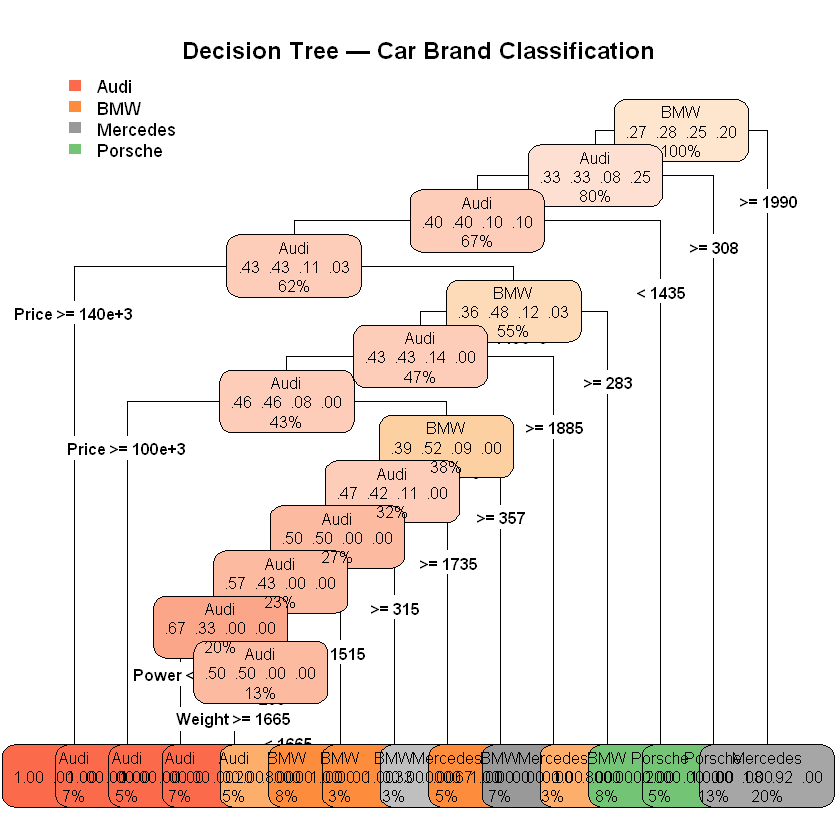

In [54]:
rpart.plot(
    model,
    type          = 4,
    extra         = 104,  
    fallen.leaves = TRUE,
    main          = "Decision Tree — Car Brand Classification",
    cex           = 0.8
)

## 7. Evaluation on the Test Set

Overall **accuracy** measures the global fraction of correct predictions, however with four overlapping classes it is essential to also inspect:

- **Confusion matrix** — shows which brands are confused with each other
- **Precision** — of all predictions for a brand shows how many were correct
- **Recall** — of all actual cars of a brand show how many were correctly identified
- **F1 score** — harmonic mean of precision and recall

In [50]:
predictions <- predict(model, test, type = "class")

# Overall accuracy
accuracy <- sum(predictions == test$Brand) / nrow(test)
cat("Test accuracy:", round(accuracy * 100, 2), "%\n\n")

# Confusion matrix
cat("Confusion Matrix:\n")
cm <- table(Predicted = predictions, Actual = test$Brand)
print(cm)

# Per-class metrics
cat("\nPer-class metrics:\n")
for (brand in levels(test$Brand)) {
    tp <- cm[brand, brand]
    fp <- sum(cm[brand, ]) - tp
    fn <- sum(cm[, brand]) - tp
    precision <- ifelse((tp + fp) == 0, 0, tp / (tp + fp))
    recall    <- ifelse((tp + fn) == 0, 0, tp / (tp + fn))
    f1        <- ifelse((precision + recall) == 0, 0,
                        2 * precision * recall / (precision + recall))
    cat(sprintf("  %-10s | Precision: %.2f | Recall: %.2f | F1: %.2f\n",
                brand, precision, recall, f1))
}

Test accuracy: 55 %

Confusion Matrix:
          Actual
Predicted  Audi BMW Mercedes Porsche
  Audi        0   1        1       0
  BMW         1   1        0       2
  Mercedes    3   1        4       0
  Porsche     0   0        0       6

Per-class metrics:
  Audi       | Precision: 0.00 | Recall: 0.00 | F1: 0.00
  BMW        | Precision: 0.25 | Recall: 0.33 | F1: 0.29
  Mercedes   | Precision: 0.50 | Recall: 0.80 | F1: 0.62
  Porsche    | Precision: 1.00 | Recall: 0.75 | F1: 0.86


## 8. Cross-Validation (10-Fold)

Using only a single train/test split with 80 observations may produce unstable estimates, therefore **10-fold cross-validation** uses all the data for both training and evaluation, providing a more reliable measure together with its standard deviation.

In [51]:
set.seed(123)
k          <- 10
folds      <- sample(rep(1:k, length.out = nrow(data)))
acc_per_fold <- numeric(k)

for (i in 1:k) {
    train_cv <- data[folds != i, ]
    test_cv  <- data[folds == i, ]
    model_cv <- rpart(
        Brand ~ Power + Weight + Price + TopSpeed + Acceleration,
        data    = train_cv,
        method  = "class",
        control = rpart.control(minsplit = 5, minbucket = 2, cp = 0.01)
    )
    preds_cv       <- predict(model_cv, test_cv, type = "class")
    acc_per_fold[i] <- sum(preds_cv == test_cv$Brand) / nrow(test_cv)
}

cat(sprintf("Mean accuracy (10-fold CV): %.2f%% +/- %.2f%%\n",
            mean(acc_per_fold) * 100, sd(acc_per_fold) * 100))
cat("Accuracy per fold:", paste(round(acc_per_fold * 100, 1), collapse = "%, "), "%\n")

Mean accuracy (10-fold CV): 67.50% +/- 13.44%
Accuracy per fold: 50%, 75%, 87.5%, 87.5%, 62.5%, 75%, 62.5%, 62.5%, 62.5%, 50 %


## 9. Complexity Parameter (cp) Analysis

The **cp** table serves to show how the relative error of the tree varies with the number of divisions. It is also useful to use the **plotcp** graph to help identify the ideal level, the **cp** value should be at the minimum cross-validation error to present a more accurate result.

Complexity parameter (cp) table:

Classification tree:
rpart(formula = Brand ~ Power + Weight + Price + TopSpeed + Acceleration, 
    data = train, method = "class", control = rpart.control(minsplit = 5, 
        minbucket = 2, cp = 0.01))

Variables actually used in tree construction:
[1] Power    Price    TopSpeed Weight  

Root node error: 43/60 = 0.71667

n= 60 

        CP nsplit rel error  xerror     xstd
1 0.232558      0  1.000000 1.18605 0.064322
2 0.186047      1  0.767442 1.06977 0.076190
3 0.081395      2  0.581395 0.74419 0.089869
4 0.038760      4  0.418605 0.72093 0.090019
5 0.034884      7  0.302326 0.58140 0.088810
6 0.010000     13  0.093023 0.53488 0.087583


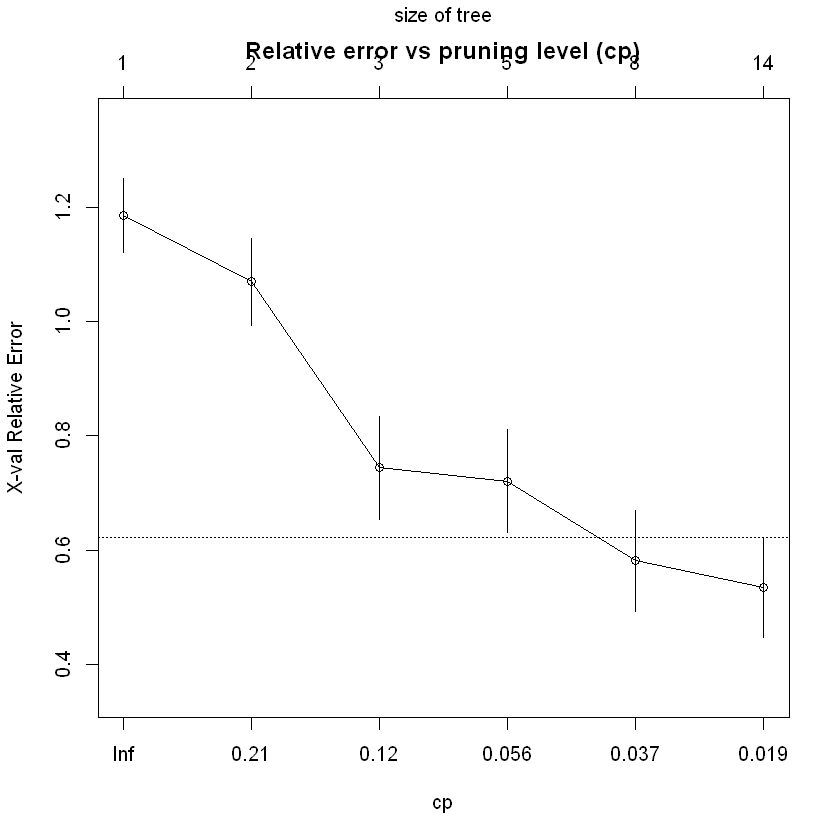

In [52]:
cat("Complexity parameter (cp) table:\n")
printcp(model)

plotcp(model, main = "Relative error vs pruning level (cp)")

## 10. Predicting a New Car

**rpart** is used to return the probability of each brand, therefore this provides a more reliable view of the model, since a probability of 80% is more informative than simply “BMW”.

In [53]:
new_car <- data.frame(
    Power        = 435,
    Weight       = 1850,
    Price        = 105000,
    TopSpeed     = 288,
    Acceleration = 4.1
)

# Predicted class
predicted_class <- predict(model, new_car, type = "class")
cat("Predicted brand:", as.character(predicted_class), "\n\n")

# Class probabilities
predicted_probs <- predict(model, new_car, type = "prob")
cat("Probability per brand:\n")
prob_df <- data.frame(
    Brand       = colnames(predicted_probs),
    Probability = paste0(round(predicted_probs[1, ] * 100, 1), "%")
)
print(prob_df[order(-predicted_probs[1, ]), ])

Predicted brand: BMW 

Probability per brand:
     Brand Probability
2      BMW         80%
4  Porsche         20%
1     Audi          0%
3 Mercedes          0%
